In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report

In [27]:
# Load the dataset
df = pd.read_excel("TrainDataset2024-Copy1.xls")

# Replace 999 with NaN for missing data analysis
df.replace(999, np.nan, inplace=True)


In [28]:
df = df.rename(columns={"pCR (outcome)": "PCR"})

In [29]:
# Replace missing values in specific features with the mode (most common value)
features_to_modify = [
    "PCR", "PgR", "HER2", "TrippleNegative", "ChemoGrade", 
    "Proliferation", "HistologyType", "LNStatus", "Gene"
]

# Loop through the columns and replace NaN values with the mode of each column
for feature in features_to_modify:
    mode_value = df[feature].mode()[0]  # Get the mode of the feature
    df[feature] = df[feature].fillna(mode_value)  # Replace NaN with the mode


In [30]:
# Drop irrelevant columns like 'ID'
df = df.drop('ID', axis=1)

# Calculate Z-scores for the entire dataset
z_scores = np.abs((df - df.mean()) / df.std())

# Identify rows that have z-scores above the threshold (3 in this case)
outliers = (z_scores > 3).any(axis=1)

# Print the number of outliers
print(f"Number of outliers: {outliers.sum()}")

# Remove outliers from the dataset
df_no_outliers = df[~outliers]


Number of outliers: 87


In [31]:
df1 = df.copy()
# checking for correlated features of dataset
def correlation(data, threshold):
    col_corr = {}  # Dictionary to store correlated features
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:  # We are interested in absolute coefficient value
                colname = corr_matrix.columns[i]
                if colname not in col_corr:
                    col_corr[colname] = set()
                col_corr[colname].add(corr_matrix.columns[j])

    return col_corr

corr_features = correlation(df1, 0.8)
print('correlated features: ', len(corr_features))

correlated features:  82


In [32]:
# removing the correlated features
df_corr= df1.drop(labels=corr_features, axis=1)
df_corr.shape

(400, 38)

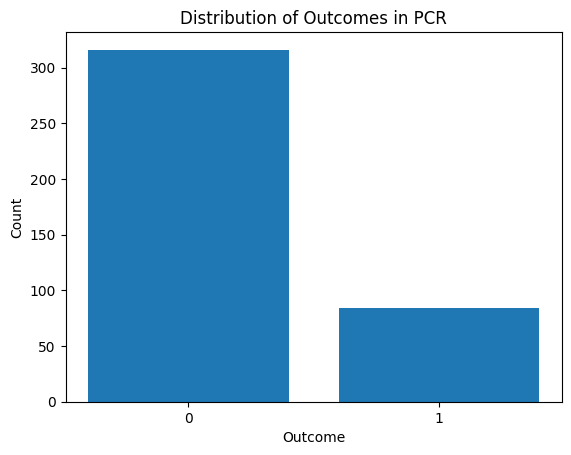

In [33]:
# checking the count of target values after data processing and feature selection
outcomes = df_corr['PCR'].value_counts()
outcome_labels =['0','1']
outcome_values = outcomes.values
plt.bar(outcome_labels, outcome_values)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Outcomes in PCR')
plt.show()

In [59]:
# dataset using correlated feature selection
X_corr = df_corr.drop(["PCR","RelapseFreeSurvival (outcome)"],axis=1)
y_corr = df_corr["PCR"]

In [60]:
X_corr.head()

,Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,HistologyType,LNStatus,TumourStage,Gene,...,original_gldm_SmallDependenceEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_LargeAreaEmphasis,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_ngtdm_Busyness,original_ngtdm_Strength
0,41.0,0,0.0,0.0,1.0,3.0,1.0,1.0,2,1.0,...,0.005563,10.779989,0.789987,27.545455,0.834711,4067578.818,0.180900,0.403535,473.464852,0.000758
1,39.0,1,1.0,0.0,0.0,3.0,1.0,1.0,2,0.0,...,0.006518,27.650685,0.442279,78.025000,0.975313,2403756.075,0.198125,0.444391,59.459710,0.003685
2,31.0,0,0.0,0.0,1.0,2.0,1.0,0.0,2,1.0,...,0.007181,25.338218,0.503046,72.027027,0.973338,1561963.432,0.275749,0.534549,33.935384,0.006447
3,35.0,0,0.0,0.0,1.0,3.0,1.0,1.0,3,1.0,...,0.004902,31.461354,0.399896,99.019802,0.980394,7007670.723,0.253014,0.506185,46.859265,0.004543
4,61.0,1,0.0,0.0,0.0,2.0,1.0,0.0,2,1.0,...,0.007222,27.916261,0.473278,56.034483,0.966112,1288913.690,0.216409,0.462282,39.621023,0.005626


In [61]:
# saving the feature in text file for future use in model training and prediction
with open('30cor.txt', 'w') as f:
    for feature in X_corr.columns:
        f.write(feature + '\n')


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Split the correlated feature into training and testing sets ( correlated features)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_corr, y_corr, test_size=0.2,shuffle=True,random_state=42)
# Standardize the features
scaler = StandardScaler()
X_train_sc1 = scaler.fit_transform(X_train1)
X_test_sc1 = scaler.fit_transform(X_test1)

In [37]:
X_train1.shape, 

((320, 36),)

In [38]:
# dataset using correlated feature selection for forward feature selection
X_for = df_corr.drop(["PCR","RelapseFreeSurvival (outcome)"],axis=1)
y_for = df_corr["PCR"]

In [39]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

# Handle missing values in y_for
y_for = y_for.dropna()  # Alternatively, use fillna()

# Ensure X_for matches the cleaned y_for
X_for = X_for.loc[y_for.index]

# Sequential Feature Selector
selector = SequentialFeatureSelector(
    estimator=RandomForestClassifier(n_estimators=100),
    n_features_to_select='auto'
)

# Fit the selector to the data
selector.fit(X_for, y_for)

# Get the selected features
selected_features1 = X_for.columns[selector.get_support()]
print("Selected features:", selected_features1)


Selected features: Index(['Age', 'ER', 'PgR', 'HER2', 'TrippleNegative', 'ChemoGrade',
       'HistologyType', 'LNStatus', 'Gene', 'original_shape_Sphericity',
       'original_firstorder_90Percentile', 'original_firstorder_Kurtosis',
       'original_firstorder_Skewness', 'original_gldm_SmallDependenceEmphasis',
       'original_glrlm_LongRunLowGrayLevelEmphasis',
       'original_glszm_GrayLevelNonUniformity',
       'original_glszm_LargeAreaEmphasis', 'original_ngtdm_Busyness'],
      dtype='object')


In [40]:
# Create a copy of the dataset with the selected features
X_selected_for1 = df_corr[selected_features1]
X_selected_for1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Age                                         400 non-null    float64
 1   ER                                          400 non-null    int64  
 2   PgR                                         400 non-null    float64
 3   HER2                                        400 non-null    float64
 4   TrippleNegative                             400 non-null    float64
 5   ChemoGrade                                  400 non-null    float64
 6   HistologyType                               400 non-null    float64
 7   LNStatus                                    400 non-null    float64
 8   Gene                                        400 non-null    float64
 9   original_shape_Sphericity                   400 non-null    float64
 10  original_first

In [41]:
# X and y for forward feature selection
df3 = df.copy()
X2 = df3[selected_features1]
y2 = df3["PCR"]

In [42]:
# Splitting the data into training and testing sets ( forward feature selection)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2,shuffle=True,random_state=42)
# Standardize the features
scaler = StandardScaler()
X_train_sc2 = scaler.fit_transform(X_train2)
X_test_sc2 = scaler.fit_transform(X_test2)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Defining hyperparameter grid for DecisionTreeClassifier
param_grid = {
    'criterion': ['entropy', 'gini'],
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [42]
}

# Instantiating DecisionTreeClassifier 
model1 = DecisionTreeClassifier()

# Creating GridSearchCV objects for dataset 1 and 2
grid_search1 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=5)
grid_search2 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=5)

# Fitting the GridSearchCV objects for dataset 1 and 2
grid_search1.fit(X_train_sc1, y_train1)
grid_search2.fit(X_train_sc2, y_train2)

# Getting the best parameters from GridSearchCV for dataset 1 and 2
best_params1 = grid_search1.best_params_
best_params2 = grid_search2.best_params_

# Printting the best parameters for each dataset
print("Dataset1:", best_params1)
print("Dataset2:", best_params2)

# Getting the balanced accuracy for the best model from GridSearchCV for each dataset
best_model1 = DecisionTreeClassifier(**best_params1)
best_model1.fit(X_train_sc1, y_train1)
y_pred1 = best_model1.predict(X_test_sc1)
balanced_accuracy1 = balanced_accuracy_score(y_test1, y_pred1)

best_model2 = DecisionTreeClassifier(**best_params2)
best_model2.fit(X_train_sc2, y_train2)
y_pred2 = best_model2.predict(X_test_sc2)
balanced_accuracy2 = balanced_accuracy_score(y_test2, y_pred2)

# Printting the balanced accuracy for each dataset
print("correlation balanced accuracy:", balanced_accuracy1)
print("forward balanced accuracy:", balanced_accuracy2)

# Getting the classification report for the best model from GridSearchCV for each dataset
print("correlation classification report:\n", classification_report(y_test1, y_pred1))
print("forward classification report:\n", classification_report(y_test2, y_pred1))

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import pandas as pd

# Handling missing values in features
imputer = SimpleImputer(strategy='mean')
X_train_sc1 = imputer.fit_transform(X_train_sc1)
X_train_sc2 = imputer.fit_transform(X_train_sc2)

# Handling missing values in targets
y_train1 = pd.Series(y_train1).fillna(pd.Series(y_train1).mode()[0])
y_train2 = pd.Series(y_train2).fillna(pd.Series(y_train2).mode()[0])

# Defining hyperparameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': [42]
}

# Instantiate RandomForestClassifier
model1 = RandomForestClassifier()

# Creating GridSearchCV objects for dataset1 and dataset2
grid_search1 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=5)
grid_search2 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=5)

# Fitting the GridSearchCV objects for dataset1 and dataset2
grid_search1.fit(X_train_sc1, y_train1)
grid_search2.fit(X_train_sc2, y_train2)

# Getting the best parameters from GridSearchCV for dataset1 and dataset2
best_params1 = grid_search1.best_params_
best_params2 = grid_search2.best_params_

# Printing the best parameters for each dataset
print("Best Parameters for Dataset 1:", best_params1)
print("Best Parameters for Dataset 2:", best_params2)

# Getting the balanced accuracy for the best model from GridSearchCV for each dataset
best_model1 = RandomForestClassifier(**best_params1)
best_model1.fit(X_train_sc1, y_train1)
y_pred1 = best_model1.predict(X_test_sc1)
balanced_accuracy1 = balanced_accuracy_score(y_test1, y_pred1)

best_model2 = RandomForestClassifier(**best_params2)
best_model2.fit(X_train_sc2, y_train2)
y_pred2 = best_model2.predict(X_test_sc2)
balanced_accuracy2 = balanced_accuracy_score(y_test2, y_pred2)

# Printing the balanced accuracy for each dataset
print("Dataset 1 Balanced Accuracy:", balanced_accuracy1)
print("Dataset 2 Balanced Accuracy:", balanced_accuracy2)

# Getting the classification report for the best model from GridSearchCV for each dataset
print("Dataset 1 Classification Report:\n", classification_report(y_test1, y_pred1))
print("Dataset 2 Classification Report:\n", classification_report(y_test2, y_pred2))

Best Parameters for Dataset 1: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100, 'random_state': 42}
Best Parameters for Dataset 2: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'random_state': 42}
Dataset 1 Balanced Accuracy: 0.5
Dataset 2 Balanced Accuracy: 0.5859375
Dataset 1 Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89        64
         1.0       0.00      0.00      0.00        16

    accuracy                           0.80        80
   macro avg       0.40      0.50      0.44        80
weighted avg       0.64      0.80      0.71        80

Dataset 2 Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.98      0.90        64
         1.0       0.75      0.19      0.30        16

    accuracy                           0.82        80
   macro avg       0.79      0.59      0.

/home/elakia/miniconda3/envs/MLE/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elakia/miniconda3/envs/MLE/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elakia/miniconda3/envs/MLE/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [46]:
# Standardize the features
scaler = StandardScaler()
X_train_sc2 = scaler.fit_transform(X_train2)
X_test_sc2 = scaler.transform(X_test2)  # Use transform here instead of fit_transform for consistency

# List of classification models to evaluate
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Support Vector Machine (SVM)': SVC(),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier()
}

# Perform K-fold Cross-validation (5 folds in this example) for each model
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results for each model
model_results = {}

for model_name, model in models.items():
    # Evaluate using K-fold cross-validation
    cv_results = cross_val_score(model, X_train_sc2, y_train2, cv=kfold, scoring='accuracy')
    
    # Store the results
    model_results[model_name] = {
        'Mean Accuracy': np.mean(cv_results),
        'Standard Deviation': np.std(cv_results)
    }

    print(f"{model_name} - Mean Accuracy: {np.mean(cv_results):.4f}, Std Dev: {np.std(cv_results):.4f}")

# Find the best model based on cross-validation performance
best_model_name = max(model_results, key=lambda x: model_results[x]['Mean Accuracy'])
best_model = models[best_model_name]
print(f"\nBest Model Based on Cross-Validation: {best_model_name}")

# Train the best model on the full training data
best_model.fit(X_train_sc2, y_train2)

# Evaluate on the test set
y_pred = best_model.predict(X_test_sc2)
test_accuracy = accuracy_score(y_test2, y_pred)
print(f"\nTest Accuracy of the Best Model: {test_accuracy:.4f}")

# Optionally: Display the classification report for detailed performance metrics
print("\nClassification Report for the Best Model:")
print(classification_report(y_test2, y_pred))

Logistic Regression - Mean Accuracy: 0.8000, Std Dev: 0.0554
Random Forest - Mean Accuracy: 0.7812, Std Dev: 0.0221
Support Vector Machine (SVM) - Mean Accuracy: 0.7906, Std Dev: 0.0480
K-Nearest Neighbors (KNN) - Mean Accuracy: 0.7531, Std Dev: 0.0435

Best Model Based on Cross-Validation: Logistic Regression

Test Accuracy of the Best Model: 0.8000

Classification Report for the Best Model:
              precision    recall  f1-score   support

         0.0       0.82      0.95      0.88        64
         1.0       0.50      0.19      0.27        16

    accuracy                           0.80        80
   macro avg       0.66      0.57      0.58        80
weighted avg       0.76      0.80      0.76        80



In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Handling missing values in features
imputer = SimpleImputer(strategy='mean')
X_train_sc1 = imputer.fit_transform(X_train_sc1)
X_test_sc1 = imputer.transform(X_test_sc1)
X_train_sc2 = imputer.fit_transform(X_train_sc2)
X_test_sc2 = imputer.transform(X_test_sc2)

# Handling missing values in targets
y_train1 = pd.Series(y_train1).fillna(pd.Series(y_train1).mode()[0])
y_train2 = pd.Series(y_train2).fillna(pd.Series(y_train2).mode()[0])

# Defining hyperparameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'random_state': [42]
}

# Instantiate RandomForestClassifier
model1 = RandomForestClassifier()

# Creating K-Fold cross-validator
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV for Dataset 1
grid_search1 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=kfold, n_jobs=-1)
grid_search1.fit(X_train_sc1, y_train1)

# GridSearchCV for Dataset 2
grid_search2 = GridSearchCV(estimator=model1, param_grid=param_grid, scoring='balanced_accuracy', cv=kfold, n_jobs=-1)
grid_search2.fit(X_train_sc2, y_train2)

# Best parameters for each dataset
best_params1 = grid_search1.best_params_
best_params2 = grid_search2.best_params_

print("Best Parameters for Dataset 1:", best_params1)
print("Best Parameters for Dataset 2:", best_params2)

# Train the best model for Dataset 1
best_model1 = grid_search1.best_estimator_
y_pred1 = best_model1.predict(X_test_sc1)
balanced_accuracy1 = balanced_accuracy_score(y_test1, y_pred1)

# Train the best model for Dataset 2
best_model2 = grid_search2.best_estimator_
y_pred2 = best_model2.predict(X_test_sc2)
balanced_accuracy2 = balanced_accuracy_score(y_test2, y_pred2)

print("Dataset 1 Balanced Accuracy:", balanced_accuracy1)
print("Dataset 2 Balanced Accuracy:", balanced_accuracy2)

# Classification report for both datasets
print("Dataset 1 Classification Report:\n", classification_report(y_test1, y_pred1))
print("Dataset 2 Classification Report:\n", classification_report(y_test2, y_pred2))

# Evaluate cross-validation performance on Dataset 1
cv_scores1 = cross_val_score(best_model1, X_train_sc1, y_train1, cv=kfold, scoring='balanced_accuracy')
print("Dataset 1 CV Scores:", cv_scores1)
print("Dataset 1 Mean CV Score:", np.mean(cv_scores1))

# Evaluate cross-validation performance on Dataset 2
cv_scores2 = cross_val_score(best_model2, X_train_sc2, y_train2, cv=kfold, scoring='balanced_accuracy')
print("Dataset 2 CV Scores:", cv_scores2)
print("Dataset 2 Mean CV Score:", np.mean(cv_scores2))

Best Parameters for Dataset 1: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100, 'random_state': 42}
Best Parameters for Dataset 2: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300, 'random_state': 42}
Dataset 1 Balanced Accuracy: 0.53125
Dataset 2 Balanced Accuracy: 0.609375
Dataset 1 Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.94      0.87        64
         1.0       0.33      0.12      0.18        16

    accuracy                           0.78        80
   macro avg       0.57      0.53      0.53        80
weighted avg       0.72      0.78      0.73        80

Dataset 2 Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.97      0.90        64
         1.0       0.67      0.25      0.36        16

    accuracy                           0.82    

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split


# Step 1: Handle Class Imbalance with SMOTE (for Dataset 1)
smote = SMOTE(random_state=42)

# If you're using different datasets, handle them separately:
X_resampled1, y_resampled1 = smote.fit_resample(X_train_sc1, y_train1)
X_resampled2, y_resampled2 = smote.fit_resample(X_train_sc2, y_train2)

# Step 2: Define RandomForestClassifier with Class Weight
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Step 3: Use Stratified KFold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 4: Hyperparameter Tuning with GridSearchCV (for Dataset 1)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

# Create GridSearchCV for Dataset 1
grid_search1 = GridSearchCV(estimator=rf, param_grid=param_grid, 
                            cv=cv, scoring='balanced_accuracy', n_jobs=-1)

grid_search1.fit(X_resampled1, y_resampled1)

# Step 5: Hyperparameter Tuning with GridSearchCV (for Dataset 2)
grid_search2 = GridSearchCV(estimator=rf, param_grid=param_grid, 
                            cv=cv, scoring='balanced_accuracy', n_jobs=-1)

grid_search2.fit(X_resampled2, y_resampled2)

# Best parameters for each dataset
best_params1 = grid_search1.best_params_
best_params2 = grid_search2.best_params_

print("Best Parameters for Dataset 1:", best_params1)
print("Best Parameters for Dataset 2:", best_params2)

# Step 6: Train the best model for Dataset 1
best_model1 = grid_search1.best_estimator_
y_pred1 = best_model1.predict(X_test_sc1)
balanced_accuracy1 = balanced_accuracy_score(y_test1, y_pred1)

# Train the best model for Dataset 2
best_model2 = grid_search2.best_estimator_
y_pred2 = best_model2.predict(X_test_sc2)
balanced_accuracy2 = balanced_accuracy_score(y_test2, y_pred2)

print("Dataset 1 Balanced Accuracy:", balanced_accuracy1)
print("Dataset 2 Balanced Accuracy:", balanced_accuracy2)

# Classification report for both datasets
print("Dataset 1 Classification Report:\n", classification_report(y_test1, y_pred1))
print("Dataset 2 Classification Report:\n", classification_report(y_test2, y_pred2))

# Step 7: Cross-validation performance for Dataset 1
cv_scores1 = cross_val_score(best_model1, X_resampled1, y_resampled1, cv=cv, scoring='balanced_accuracy')
print("Dataset 1 CV Scores:", cv_scores1)
print("Dataset 1 Mean CV Score:", np.mean(cv_scores1))

# Step 8: Cross-validation performance for Dataset 2
cv_scores2 = cross_val_score(best_model2, X_resampled2, y_resampled2, cv=cv, scoring='balanced_accuracy')
print("Dataset 2 CV Scores:", cv_scores2)
print("Dataset 2 Mean CV Score:", np.mean(cv_scores2))


Best Parameters for Dataset 1: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Parameters for Dataset 2: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Dataset 1 Balanced Accuracy: 0.578125
Dataset 2 Balanced Accuracy: 0.6015625
Dataset 1 Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.59      0.70        64
         1.0       0.26      0.56      0.35        16

    accuracy                           0.59        80
   macro avg       0.55      0.58      0.53        80
weighted avg       0.73      0.59      0.63        80

Dataset 2 Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.89      0.86        64
         1.0       0.42      0.31      0.36        16

    accuracy                           0.78        80
   macro avg       0.63      0.6

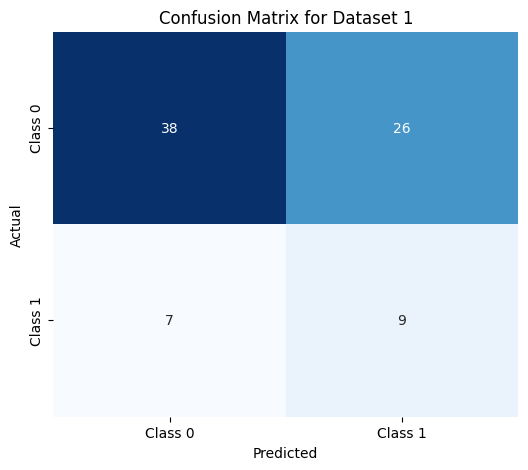

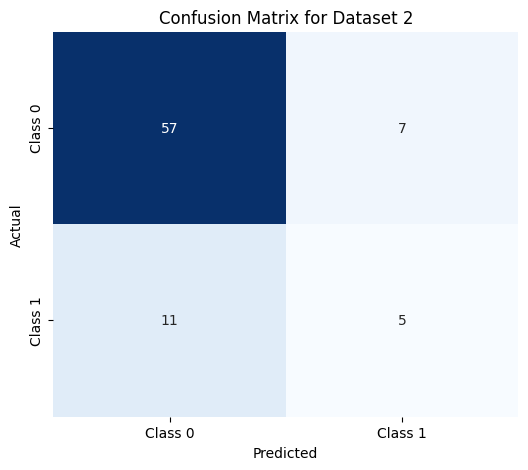

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for Dataset 1
cm1 = confusion_matrix(y_test1, y_pred1)
# Generate confusion matrix for Dataset 2
cm2 = confusion_matrix(y_test2, y_pred2)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, labels, title='Confusion Matrix'):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot confusion matrices
labels = ['Class 0', 'Class 1']  # Update this if you have more classes
plot_confusion_matrix(cm1, labels, 'Confusion Matrix for Dataset 1')
plot_confusion_matrix(cm2, labels, 'Confusion Matrix for Dataset 2')


In [76]:
import joblib

# Save the best model for Dataset 1
joblib.dump(best_model1, 'best_random_forest_model_dataset1.pkl')

print("Model for Dataset 1 has been saved successfully.")

Model for Dataset 1 has been saved successfully.


In [79]:
# Step 1: Load the features from 30cor.txt
# Assuming the features are in a text file, one feature per line
with open('30cor.txt', 'r') as file:
    features = [line.strip() for line in file.readlines()]

# Step 2: Prepare the test data with the loaded features
# Assuming that your test data is stored in a DataFrame or comes in a structured format
# Load the test dataset (replace this with how you load your data)
df_test = pd.read_excel("TestDatasetExample.xls")

# Select only the features that are in the loaded list
df_test_selected = df_test[features]

# Step 3: Scale the test data (using the same scaler as used during training)
scaler = StandardScaler()  # Or load the scaler if you saved it during training
# If you saved the scaler, you can load it:
# scaler = joblib.load('scaler.pkl')
X_test_sc = scaler.fit_transform(df_test_selected)

# Step 4: Load the trained model (from the .pkl file)
best_model1 = joblib.load('best_random_forest_model_dataset1.pkl')

# Step 5: Make predictions on the test dataset
y_pred = best_model1.predict(X_test_sc)

# Step 6: Print the predictions
print("Predictions on Test Dataset:", y_pred)



Predictions on Test Dataset: [1. 1. 1.]
